In [1]:
from ultralytics import YOLO
import os
import hierarchical_yolo.yolo_utils
import hierarchical_loss.path_utils
import hierarchical_loss.viz_utils
import ultralytics
import torch
import itertools
from PIL import Image
from gfisher_data_hierarchical_model.gfisher_hierarchical_model import GFISHERHierarchicalDetectionTrainer
trainer = GFISHERHierarchicalDetectionTrainer

In [2]:
# Ultralytics default settings.  See https://docs.ultralytics.com/quickstart/#ultralytics-settings
# The root directory where datasets are expected to be stored, and where ultralytics will download curated datasets
#DATASETS = ultralytics.settings['datasets_dir']
DATASETS = os.path.expanduser('~/datasets')
# The root directory for model weights.  In particular, where ultralytics will download pre-trained model .pt weight files
#WEIGHTS = ultralytics.settings['weights_dir']
WEIGHTS = os.path.expanduser('~/Models/weights')
# The root directory where training runs will be stored, including evaluation artifacts and trained model .pt weight files
#RUNS = ultralytics.settings['runs_dir']
RUNS = os.path.expanduser('~/Models/runs')

# The pre-trained model to use.  Note the v8 (version 8) and the n (nano-scale)
YOLO_BASE_WEIGHTS = os.path.join(WEIGHTS, "yolov8n.pt")

# Configure project runs save locations.
BASE_PROJECT = os.path.join(RUNS, 'gfisher')
HIERARCHICAL_PROJECT = os.path.join(RUNS, 'hierarchical_gfisher')

# Find where data is downloaded/stored.  This is where ultralytics will download the coco128 data.
DATA = os.path.join(DATASETS, 'gfisher')
IMAGES_PATH = os.path.join(DATA, 'hierarchical_annotations', 'images')

# Find model configurations.  These are in the repository https://github.com/csbrown-noaa/hierarchical_yolo.
# If you aren't running this from the cloned repo, you will need to go acquire these and change MODEL_CONFIGS to reflect the location of the model config files.
MODEL_CONFIGS = '../gfisher_data_hierarchical_model/models'
YOLO_MODEL_YAML = os.path.join(MODEL_CONFIGS, 'hierarchicalgfisheryolov8.yaml')
YOLO_DATASET_YAML = os.path.join(MODEL_CONFIGS, 'hierarchical_gfisher.yaml')

In [3]:
devices = list(range(torch.cuda.device_count()))
devices = devices[0] if devices else 'cpu'

In [4]:
# Find the latest model from the last training run for this project
trained_models = os.listdir(HIERARCHICAL_PROJECT)
model_numbers = list(map(lambda x: int(x[len('train'):]) if len(x) > len('train') else 0, trained_models))
latest_model = 'train' + str(max(model_numbers))
latest_model

'train73'

In [5]:
# Load up the weights from the last training run in evaluation mode
trained_model = (
    YOLO(os.path.join(HIERARCHICAL_PROJECT, latest_model, 'weights', 'best.pt')).to(0)
)
trained_model.eval()

YOLO(
  (model): HierarchicalDetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, tra

In [6]:
image_filenames = [filename for filename in os.listdir(IMAGES_PATH) if filename.endswith('.jpg')]

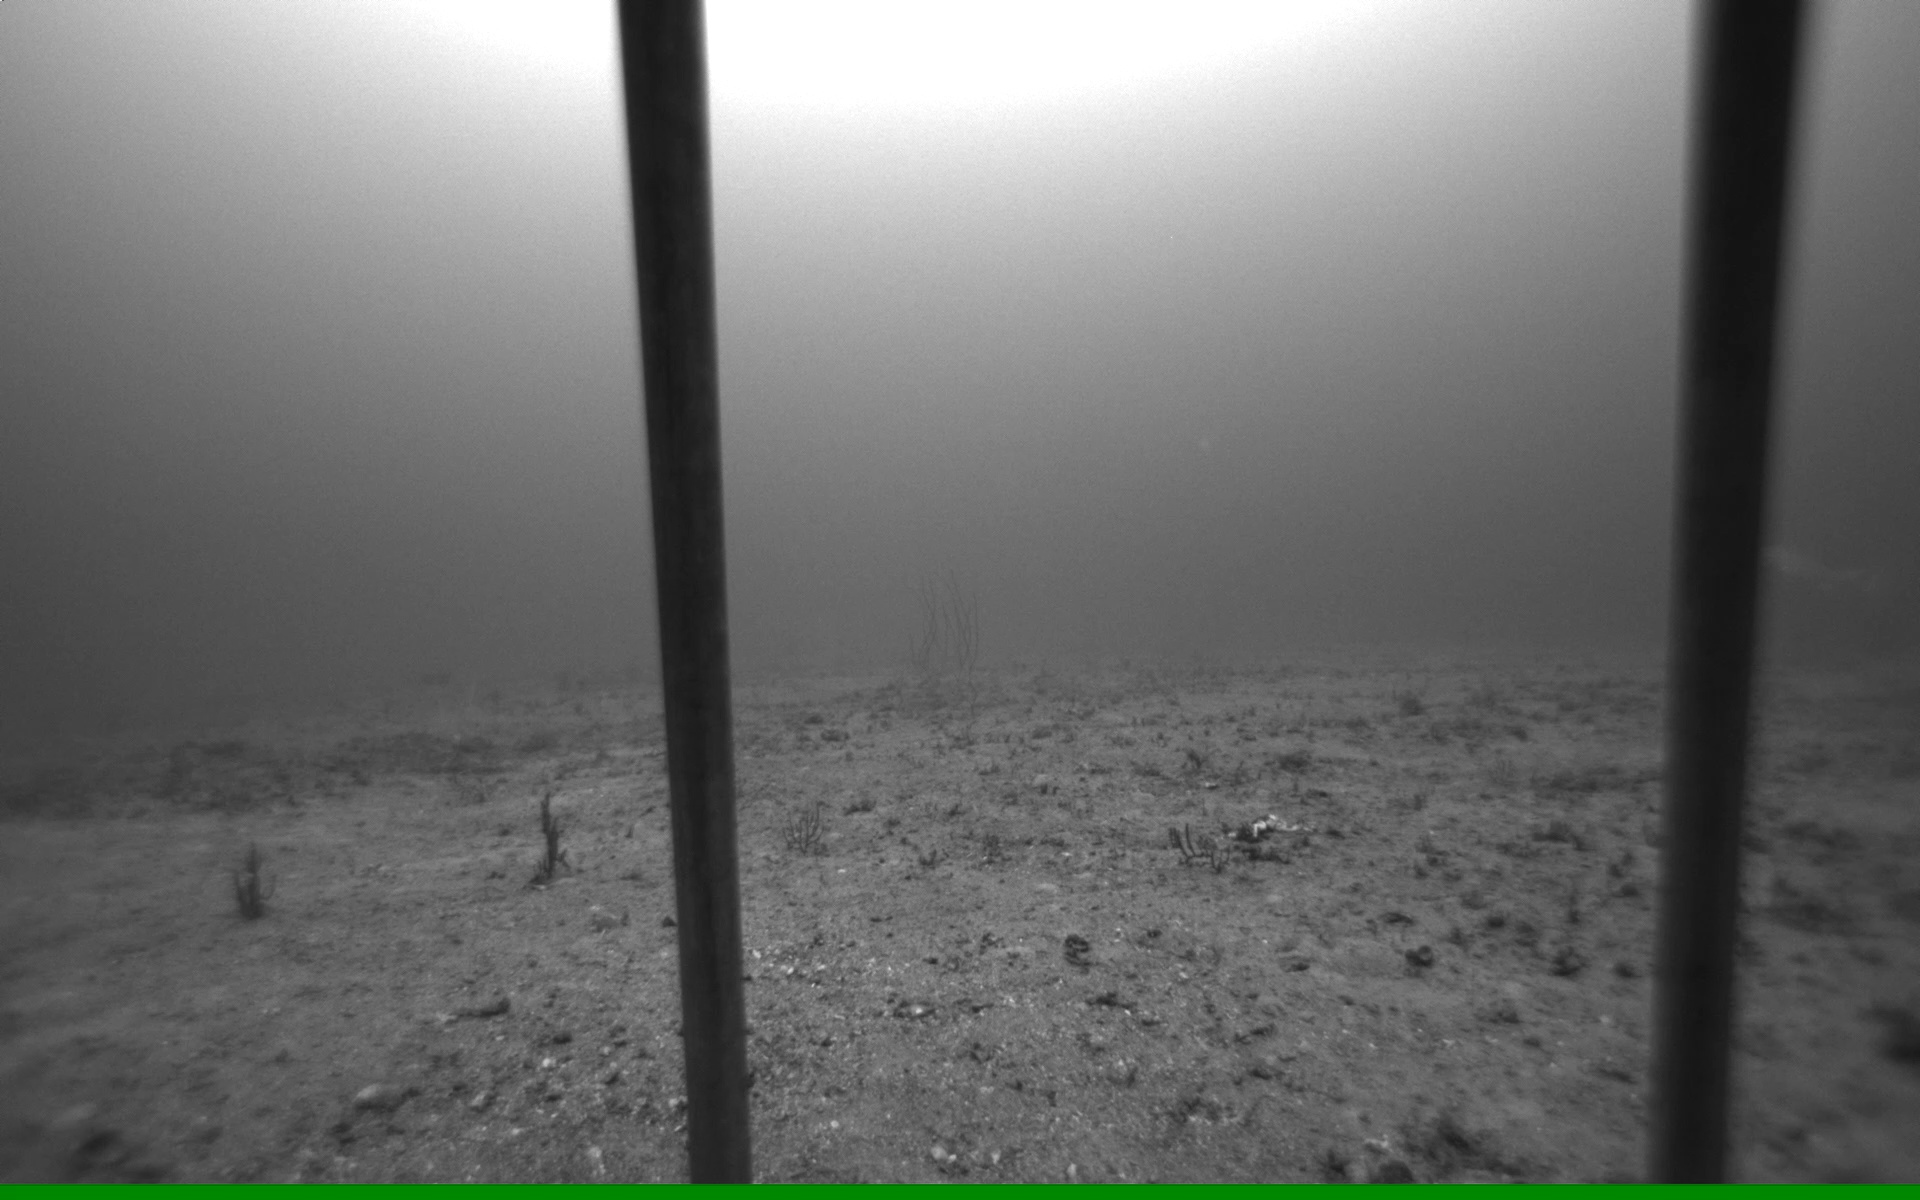

In [7]:
# load in a test image from the training dataset.
#image_path = os.path.join(IMAGES_PATH, '000000000257.jpg')
images_path = [os.path.join(IMAGES_PATH, img) for img in image_filenames]
image = Image.open(images_path[0]).convert('RGB')
image

In [8]:
BATCH_SIZE = 20
SAMPLE_SIZE = 1000
val_boxes, val_preds = [], [] 
for i, batch in enumerate(itertools.batched(images_path[::max(1, int(len(images_path)/SAMPLE_SIZE))], BATCH_SIZE)):
    print(i)
    images = [Image.open(img).convert('RGB') for img in batch]
    raw_predictions = hierarchical_yolo.yolo_utils.yolo_raw_predict(trained_model, images, (640, 640))
    boxes, preds = hierarchical_yolo.yolo_utils.postprocess_raw_output(raw_predictions, trainer._hierarchy.index_tree, nms_conf_thres=0.05)
    val_boxes.append(boxes)
    val_preds.append(preds)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


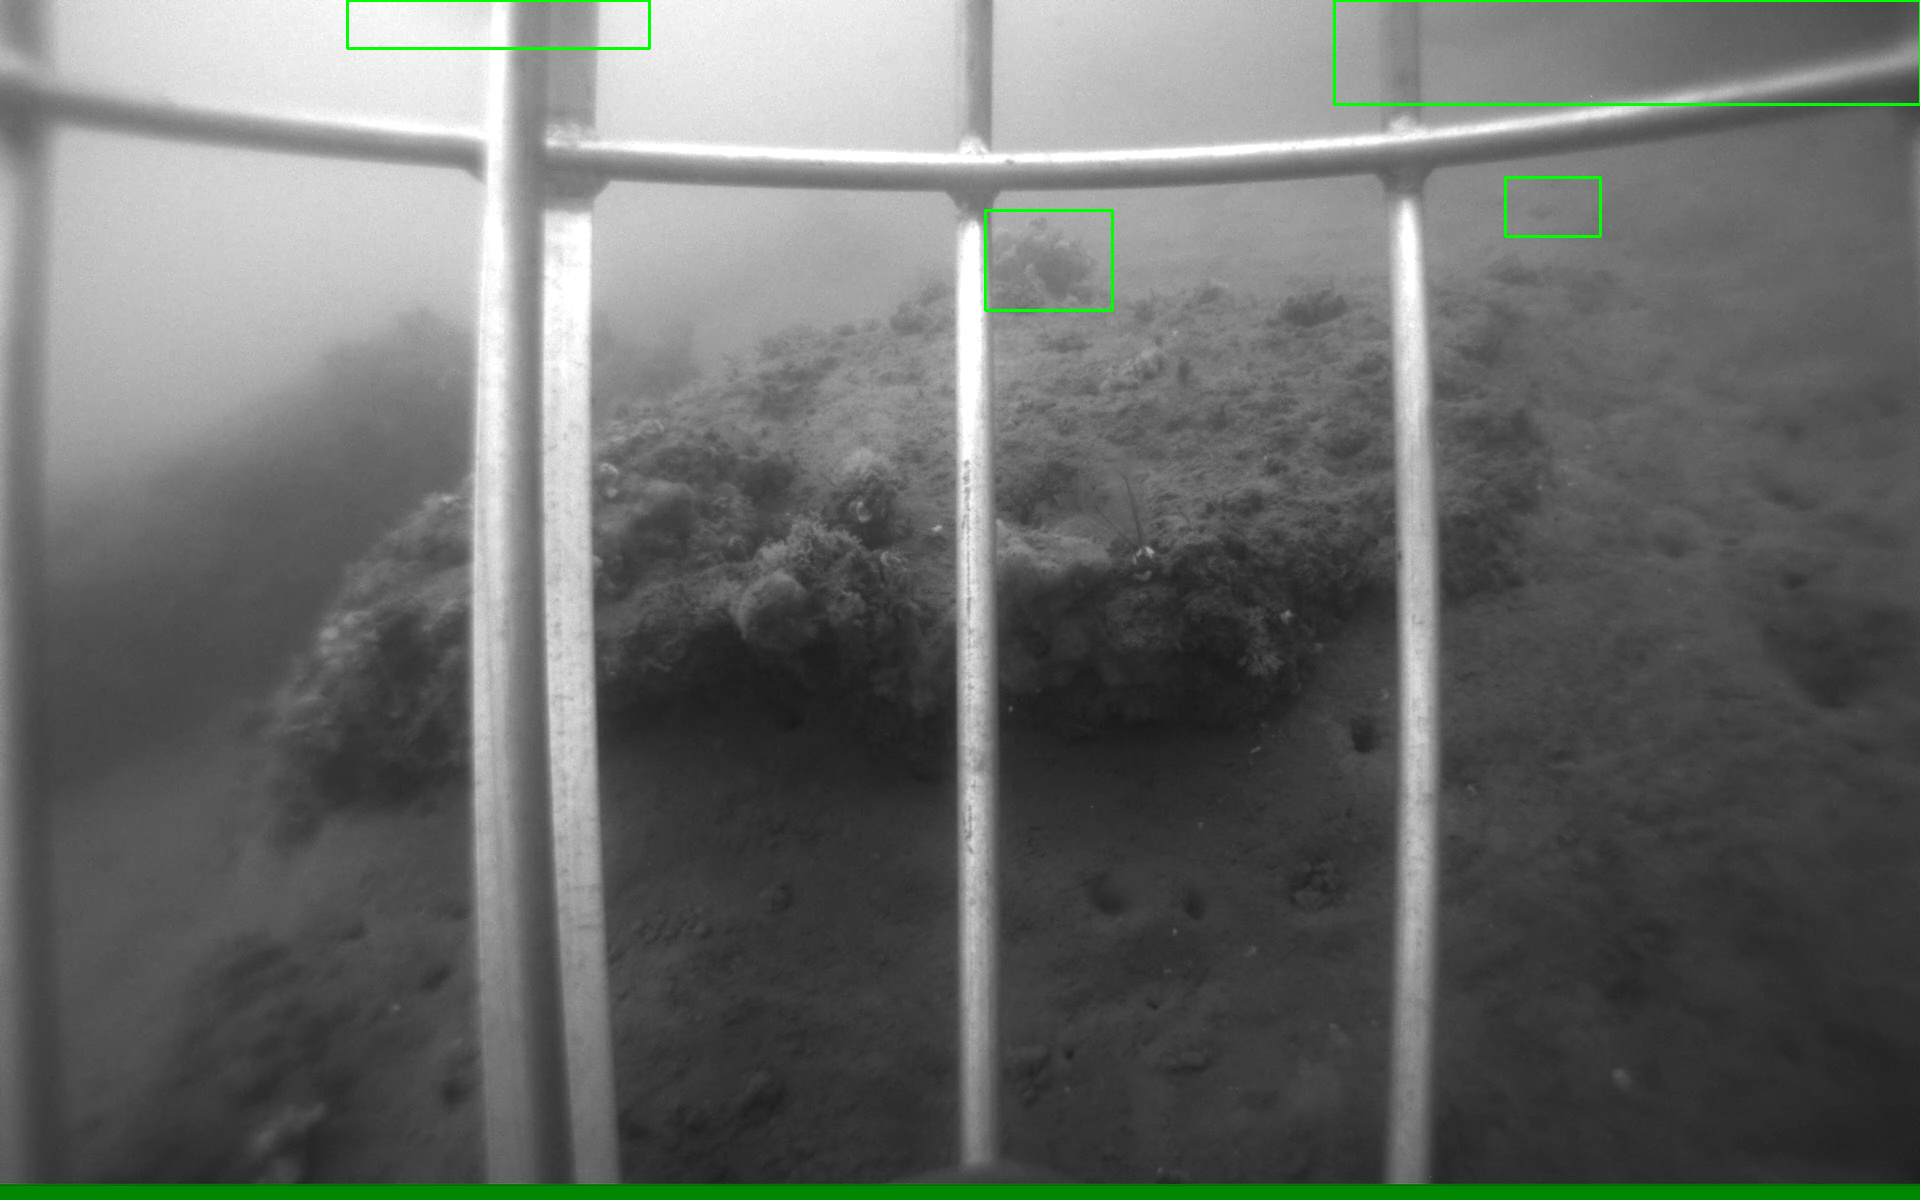

In [9]:
hierarchical_loss.viz_utils.draw_boxes_on_image(images[-1], val_boxes[-1][-1].T, 
                    box_color=(0, 255, 0), text_color=(255, 255, 255))

In [10]:
PUBLIC_COCO_URL_ROOT = 'https://storage.googleapis.com/nmfs_odp_hq/nodd_tools/datasets/gfisher/'

categories = [
    {
        'name': name,
        'id': i
    } for i, name in trainer._hierarchy.idx_to_node.items()
]
images = []
for i, filename in enumerate(image_filenames):
    station = filename.split('.')[0]
    width, height = Image.open(os.path.join(IMAGES_PATH, filename)).size
    images.append(
        {
            'id': i,
            'file_name': filename,
            'coco_url': PUBLIC_COCO_URL_ROOT + station + '/' + filename,
            'width': width,
            'height': height
        }
    )
annotations = []
img_idx = 0
ann_idx = 0
for pred_batch, box_batch in zip(val_preds, val_boxes):
    for preds, boxes in zip(pred_batch, box_batch):
        img_w = images[img_idx]['width']
        img_h = images[img_idx]['height']
        scale_w = img_w/640
        scale_h = img_h/640
        for pred, box in zip(preds.T, boxes.T):
            annotations.append( 
                {
                    'id': ann_idx,
                    'image_id': img_idx,
                    'bbox': [
                        int(box[0] * scale_w),
                        int(box[1] * scale_h),
                        int((box[2] - box[0])*scale_w),
                        int((box[3] - box[1])*scale_h)
                    ],
                    'category_id': trainer._hierarchy.roots[0].item(),
                    'scores': [f'{x.item():.5f}' for x in pred]
                }
            )
            annotations[-1]['area'] = annotations[-1]['bbox'][-1] * annotations[-1]['bbox'][-2]
            ann_idx += 1
        img_idx += 1
            
new_coco = {
    'images': images,
    'annotations': annotations,
    'categories': categories
}

In [11]:
len(new_coco['images'])

231620

In [12]:
len(annotations)

21147

In [13]:
(
    new_coco['images'][0],
    new_coco['annotations'][0],
    new_coco['categories'][0]
)

({'id': 0,
  'file_name': '2021_NCD-047b.mp4.00.00.00.000000.jpg',
  'coco_url': 'https://storage.googleapis.com/nmfs_odp_hq/nodd_tools/datasets/gfisher/2021_NCD-047b/2021_NCD-047b.mp4.00.00.00.000000.jpg',
  'width': 1920,
  'height': 1200},
 {'id': 0,
  'image_id': 0,
  'bbox': [1179, 421, 49, 40],
  'category_id': 26,
  'scores': ['0.00000',
   '0.00005',
   '0.00001',
   '0.00058',
   '0.00001',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00019',
   '1.00000',
   '0.00282',
   '0.00001',
   '0.00000',
   '0.05858',
   '0.00037',
   '0.00000',
   '0.00000',
   '0.00000',
   '0.00008',
   '0.00000',
   '0.00001',
   '0.00009',
   '0.00000',
   '0.00000',
   '1.00000',
   '0.00014',
   '0.00000',
   '0.00365',
   '0.00004',
   '0.82151',
   '0.00002',
   '0.12178',
   '0.00000',
   '0.00049',
   '0.00000',
   '0.00001',
   '0.00000',
   '0.00001',
   '0.00000',
   '0.00011',
   '0.00000',
   '0.00000',
   '0.00004',
   '0.00001',
   '0.00002',
   '0.000

In [14]:
import json
with open('hierarchical_gfisher_preds_' + str(max(model_numbers)) + '.json','w') as f:
    json.dump(new_coco, f)